<a href="https://colab.research.google.com/github/younesseoutolbadoc-alt/Ecole_doctorale_2026/blob/main/OUTOLBA_YOUNESSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombre d'observations : 20000
Nombre de variables (features) : 8

Exemple de 5 premières lignes :
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  MedHouseVal  
0      1015.0       472.0         1.4936      66900.0  
1      1129.0       463.0         1.8200      80100.0  
2       333.0       117.0         1.6509      85700.0  
3       515.0       226.0         3.1917      73400.0  
4       624.0       262.0         1.9250      65500.0  

Statistiques descriptives des variables numériques :
                      count           mean            std    

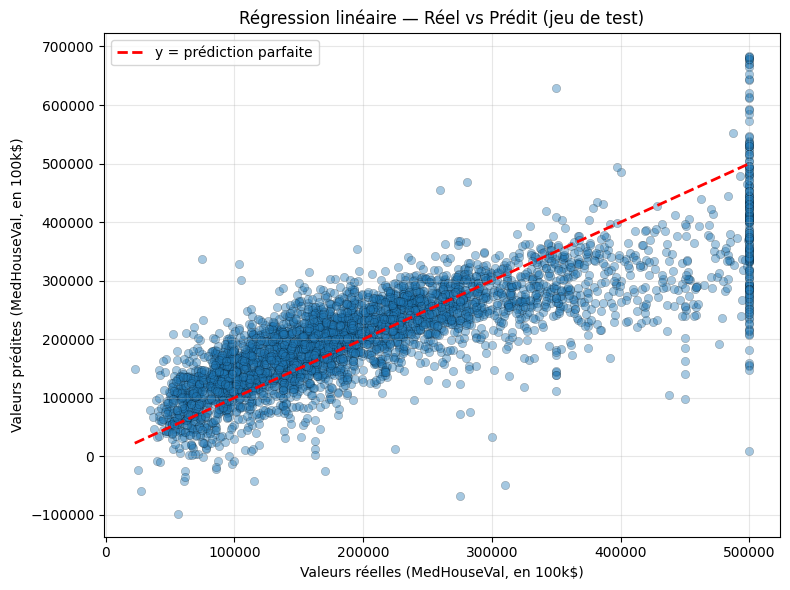

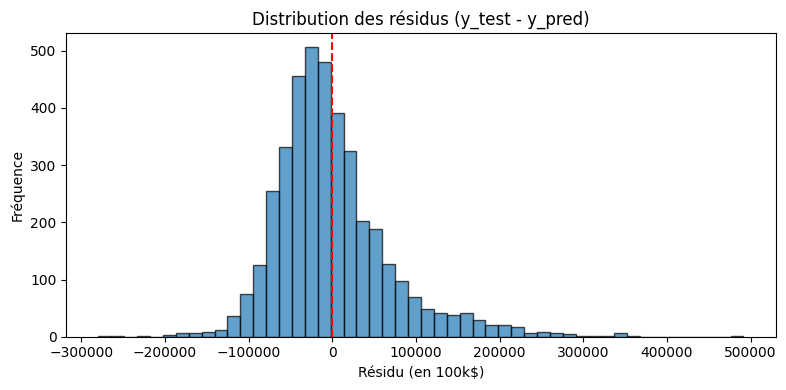

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1) Chargement et exploration rapide des données
# ---------------------------------------------------------------------
# Charger les jeux de données d'entraînement et de test locaux
train_df = pd.read_csv('/content/sample_data/california_housing_train.csv')
test_df = pd.read_csv('/content/sample_data/california_housing_test.csv')

# Concaténer pour former le dataset complet
full_df = pd.concat([train_df, test_df], ignore_index=True)

# Séparer les caractéristiques (X) et la variable cible (y)
X = full_df.drop(columns=['median_house_value']) # DataFrame des caractéristiques
y = full_df['median_house_value'] # Série des cibles

# Renommer la variable cible pour être cohérent avec le reste du code
df = pd.concat([X, y.rename("MedHouseVal")], axis=1)

# Nombre d'observations et de variables
n_obs, n_vars = X.shape
print(f"Nombre d'observations : {n_obs}")
print(f"Nombre de variables (features) : {n_vars}")

# Affichage rapide
print("\nExemple de 5 premières lignes :")
print(df.head())

print("\nStatistiques descriptives des variables numériques :")
print(df.describe().T)

# (Optionnel) matrice de corrélation rapide
print("\nCorrélations (avec la variable cible triées par valeur absolue) :")
corr_with_target = df.corr()["MedHouseVal"].abs().sort_values(ascending=False)
print(corr_with_target)

# Brève explication :
# - Le dataset California Housing contient des observations (n_obs) de quartiers,
# avec plusieurs variables explicatives (n_vars) telles que MedInc, HouseAge, etc.
# - La cible `MedHouseVal` est la valeur médiane des maisons (en 100k$).

# 2) Séparation train/test (80/20)
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nTaille train : {X_train.shape[0]} observations")
print(f"Taille test : {X_test.shape[0]} observations")

# 3) Entraînement du modèle
# ------------------------------------------------------------------------------------
model = LinearRegression()
model.fit(X_train,y_train)

# Optionnel : coefficients du modèle (interprétation linéaire)
coeffs = pd.Series(model.coef_, index=X.columns)
print("\nCoefficients du modèle (feature coef) :")
print(coeffs.sort_values(key=abs, ascending=False))

# 4) Prédiction et évaluation (R², MAE, RMSE)
# ---------------------------------------------------------------------
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Calcule RMSE en prenant la racine carrée du MSE

print("\nMétriques d'évaluation sur le jeu de test :")
print(f"R² : {r2:.4f}")
print(f"MAE : {mae:.4f} (unité = valeur médiane de la maison en 100k$)")
print(f"RMSE : {rmse:.4f} (unité = valeur médiane de la maison en 100k$)")

# 5) Visualisation des résultats (valeurs réelles vs prédites)
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='y = prédiction parfaite')
plt.xlabel("Valeurs réelles (MedHouseVal, en 100k$)")
plt.ylabel("Valeurs prédites (MedHouseVal, en 100k$)")
plt.title("Régression linéaire — Réel vs Prédit (jeu de test)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Visualisation des résidus (optionnel)
résiduels = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.hist(résiduels, bins=50, edgecolor='k', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution des résidus (y_test - y_pred)")
plt.xlabel("Résidu (en 100k$)")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

# Brève explication finale et interprétation des métriques :
# ------------------------------------------------------------------------------------
# - R² (coefficient de détermination) : proportion de la variance de la variable
# cible expliquée par le modèle. Varie entre -inf et 1. Une valeur proche de 1
# signifie que le modèle explique bien la variabilité des données.
# Interprétation pratique :
# * R² >= 0.7 : excellent (pour beaucoup de problèmes réels, rare en pratique)
# * 0.4 <= R² < 0.7 : raisonnable/modéré
# * R² < 0.4 : faible (le modèle linéaire n'explique pas bien la cible)
#
# - MAE (Mean Absolute Error) :erreur moyenne absolue entre prédictions et réelles.
# Donne une idée en unités de la cible (ici 100k$). Plus petit est le meilleur.
#
# - RMSE (Root Mean Squared Error) : racine de l'erreur quadratique moyenne.
# Pénalise davantage les grandes erreurs que le MAE. Interprétation :
# * Si RMSE est petit comparé à l'échelle typique de la cible, les prédictions
# sont précises. Par exemple, si la médiane des maisons est ~2.0 (200k$)
# et RMSE = 0.5, l'erreur-type est ~50k$.
#
# Exemples d'interprétation concrète (avec valeurs fictives) :
# - Si R² = 0.60, MAE = 0.40, RMSE = 0.60 :
# Le modèle explique ~60% de la variance ; l'erreur moyenne est 40k$,
# l'erreur-type (RMSE) est 60k$. Les prédictions sont utiles mais encore
# loin d'être parfaites pour des décisions très sensibles au prix.
#
# Remarques pratiques :
# - La régression linéaire est simple et interprétable ; si R² est faible,
# penser à : ingénierie des fonctionnalités, transformations (log, polynômes),
# régularisation (Ridge/Lasso), ou modèles non-linéaires (RandomForest, XGBoost).
# - Toujours vérifier les résidus (non corrélation, distribution proche de 0)
# pour valider certaines hypothèses du modèle linéaire.
#
# Fin de l'exemple.